In [63]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ['PLY.AX', 'LAU.AX', 'COS.AX', 'ANG.AX', 'VVA.AX',
           'WTC.AX', 'AUB.AX', 'TLX.AX', 'DUG.AX']

data = yf.download(tickers, period='5y', interval='1d')['Close']

daily_log_returns = np.log(data / data.shift(1))

monthly_prices = data.resample('ME').last()
monthly_returns = np.log(monthly_prices / monthly_prices.shift(1))[1:]

monthly_volatility = daily_log_returns.resample('ME').std()[1:]

result = pd.concat({
    'monthly_return': monthly_returns,
    'monthly_vol': monthly_volatility
}, axis=1).dropna()

print(monthly_returns.shape, monthly_volatility.shape)

[*********************100%***********************]  9 of 9 completed

(60, 9) (60, 9)


In [64]:
import statsmodels.api as sm

results = {}

for stock in monthly_returns.columns:
    y = monthly_returns[stock]
    x = monthly_volatility[stock]
    
    x = sm.add_constant(x)
    
    model = sm.OLS(y, x).fit()
    results[stock] = model
    
    print(f"\n{stock}")
    print(model.summary())


ANG.AX
                            OLS Regression Results                            
Dep. Variable:                 ANG.AX   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     3.156
Date:                Sun, 26 Apr 2026   Prob (F-statistic):             0.0809
Time:                        21:14:44   Log-Likelihood:                 36.090
No. Observations:                  60   AIC:                            -68.18
Df Residuals:                      58   BIC:                            -63.99
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0842      0.047      1.795 

In [65]:
momentum = monthly_returns.rolling(window=3).sum().shift(1)
momentum = momentum.dropna()

volume_data = yf.download(tickers, period='5y', interval='1d')['Volume']
liquidity = np.log(volume_data.resample('ME').sum())

market_data = yf.download('^AXJO', period='5y', interval='1d')['Close']
market_data = market_data.resample('ME').last()
market_ret = np.log(market_data/market_data.shift(1)).dropna()

market_ret_df = pd.DataFrame(
    np.tile(market_ret.values.reshape(-1, 1), (1, len(tickers))),
    index=market_ret.index,
    columns=tickers
)

df = pd.concat({
    'return': monthly_returns,
    'vol': monthly_volatility,
    'momentum': momentum,
    'liquidity': liquidity,
    'market performance': market_ret_df
}, axis=1).dropna()


[*********************100%***********************]  9 of 9 completed
[*********************100%***********************]  1 of 1 completed
C:\Users\suhit\AppData\Local\Temp\ipykernel_32480\1092102379.py:17: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df = pd.concat({


In [66]:
print(market_ret_df.columns)

Index(['PLY.AX', 'LAU.AX', 'COS.AX', 'ANG.AX', 'VVA.AX', 'WTC.AX', 'AUB.AX',
       'TLX.AX', 'DUG.AX'],
      dtype='str')


In [67]:
betas = pd.DataFrame()
r_sq = {}

for stock in tickers:
    
    y = df['return'][stock]
    
    X = pd.concat([
        df['vol'][stock],
        df['momentum'][stock],
        df['liquidity'][stock],
        df[('market performance', stock)]
    ], axis=1)
    
    X.columns = ['vol', 'momentum', 'liquidity', 'market performance']
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={'maxlags':5})
    
    betas[stock] = model.params
    r_sq[stock] = model.rsquared

betas = betas.T
r_sq = pd.Series(r_sq)

print(betas)
print(f"\n{r_sq}")

           const       vol  momentum  liquidity  market performance
PLY.AX  0.206419 -1.948805  0.123421  -0.007496            1.621481
LAU.AX  0.033046  3.827858 -0.035846  -0.007273            0.806548
COS.AX  0.356430 -3.492432 -0.070169  -0.019633            0.500300
ANG.AX  0.333816 -1.671578 -0.021020  -0.016334            1.007462
VVA.AX -0.443838  2.360246 -0.030349   0.026409            0.591558
WTC.AX  1.630360  0.758584 -0.047775  -0.100153            1.783054
AUB.AX  0.829008 -3.172885 -0.184032  -0.049362            0.625112
TLX.AX  1.471512 -0.748578 -0.062174  -0.083698            1.013016
DUG.AX -0.206092  7.159951  0.215355  -0.002244            0.411104

PLY.AX    0.171587
LAU.AX    0.146152
COS.AX    0.345206
ANG.AX    0.143589
VVA.AX    0.131586
WTC.AX    0.314076
AUB.AX    0.336378
TLX.AX    0.115529
DUG.AX    0.245312
dtype: float64


In [68]:
factor_returns = {}

for month in df.index:
    y = df.loc[month, 'return']   
    
    X = pd.concat([
        df.loc[month, 'vol'],
        df.loc[month, 'momentum'],
        df.loc[month, 'liquidity']
    ], axis=1)
    
    X.columns = ['vol', 'momentum', 'liquidity']
    X = sm.add_constant(X)
    
    model = sm.OLS(y, X).fit()
    factor_returns[month] = model.params

factor_returns = pd.DataFrame(factor_returns).T

print(factor_returns)

               const        vol  momentum  liquidity
2021-08-31 -1.003604   6.119384  0.055688   0.054348
2021-09-30 -0.174371   8.282440 -0.053514  -0.000926
2021-10-31 -0.689897  16.014408 -0.118223   0.019539
2021-11-30  0.610557  -1.024027  0.256528  -0.040651
2021-12-31 -0.552643   1.369747  0.113397   0.037177
2022-01-31  0.022353   3.712722 -0.139821  -0.014757
2022-02-28  0.572044   2.373137 -0.115985  -0.044717
2022-03-31 -0.096304  -5.663853  0.156376   0.018998
2022-04-30  0.317203   1.603201 -0.137872  -0.026443
2022-05-31  0.078029  -6.750582 -0.665810   0.001750
2022-06-30 -0.180635   3.027039  1.310016   0.005555
2022-07-31 -0.711125   3.413990  0.110873   0.051914
2022-08-31 -1.202433  -0.361817 -0.598671   0.083339
2022-09-30  0.553339  -1.914023  0.276168  -0.042407
2022-10-31 -1.654117   4.657566 -0.001444   0.101825
2022-11-30  0.314423  -1.179615 -0.303234  -0.012670
2022-12-31 -0.122374   7.175556  0.415288  -0.005007
2023-01-31  0.524016  -0.889192 -0.169081  -0.

In [69]:
industry_map = {"PLY.AX": "Communication Services", 
    "LAU.AX": "Industrials", "ANG.AX": "Industrials",
    "TLX.AX": "Health Care", 
    "COS.AX": "Information Technology", "WTC.AX": "Information Technology", "DUG.AX": "Information Technology",
    "VVA.AX": "Consumer Discretionary",
    "AUB.AX": "Financials"}

industry_factors = {}

industries = sorted(set(industry_map.values()))

for ind in industries:
    dummy = pd.DataFrame(
        0, index=monthly_returns.index, columns=monthly_returns.columns)

    for stock in dummy.columns:
        if industry_map[stock] == ind:
            dummy.loc[:, stock] = 1

    industry_factors[f'ind_{ind}'] = dummy

cs_mean = monthly_prices.mean(axis=1)
cs_std  = monthly_prices.std(axis=1, ddof=1)
cs_std = cs_std.replace(0, np.nan)
price_std = monthly_prices.sub(cs_mean, axis=0).div(cs_std, axis=0)



In [70]:
factors = {
    'vol': df['vol'],
    'momentum': df['momentum'],
    'liquidity': df['liquidity'],
    'market performance': df['market performance'],
    'size': price_std,
    'return': df['return']
}
df_std = {}

for factor in factors:
    if factor != 'return':
        raw = factors[factor]

        cs_mean = raw.mean(axis=1)
        cs_std = raw.std(axis=1, ddof=1)

        df_std[factor] = raw.sub(cs_mean, axis=0).div(cs_std, axis=0)
    else:
        df_std[factor] = factors[factor]

In [71]:
target_index = df_std['return'].index
df_std['size'] = df_std['size'].loc[target_index]
for ind in industries:
    industry_factors[f'ind_{ind}'] = industry_factors[f'ind_{ind}'].loc[target_index]


In [72]:
betas_z = pd.DataFrame()
r_sq_z = {}
cs_residuals = {}

for stock in tickers:

    y = df_std['return'][stock]

    X = pd.concat([
        df_std['vol'][stock],
        df_std['momentum'][stock],
        df_std['liquidity'][stock],
        df_std['size'][stock],
    ] + [
        industry_factors[f'ind_{ind}'][stock] for ind in industries[:-1]
    ], axis=1)

    X.columns = ['vol', 'momentum', 'liquidity', 'size'] + industries[:-1]
    X = sm.add_constant(X)

    model = sm.OLS(y, X, missing='drop').fit(
        cov_type='HAC',
        cov_kwds={'maxlags': 5}
    )

    betas_z[stock] = model.params
    r_sq_z[stock] = model.rsquared
    cs_residuals[stock] = model.resid


betas_z = betas_z.T
r_sq_z = pd.Series(r_sq_z)
cs_residuals = pd.DataFrame(cs_residuals, index=df_std['return'].index)
print(betas_z)
print(f"\n{r_sq_z}")

             vol  momentum  liquidity      size  Communication Services  \
PLY.AX  0.014037  0.037739  -0.040030  0.599805                0.297251   
LAU.AX  0.016674  0.009094   0.015658  0.698068                0.000000   
COS.AX -0.033256 -0.049612   0.018488  1.747083                0.000000   
ANG.AX -0.019888 -0.011347  -0.024217  0.865729                0.000000   
VVA.AX  0.057858 -0.032884  -0.005974 -0.168113                0.000000   
WTC.AX  0.016145 -0.071235   0.007136  1.056102                0.000000   
AUB.AX -0.046045 -0.035739  -0.073923 -0.022796                0.000000   
TLX.AX  0.028376 -0.008495  -0.079623  0.252243                0.000000   
DUG.AX  0.093763  0.028136  -0.045208  1.894910                0.000000   

        Consumer Discretionary  Financials  Health Care  Industrials  
PLY.AX                0.000000    0.000000     0.000000     0.000000  
LAU.AX                0.000000    0.000000     0.000000     0.369475  
COS.AX                0.000000    0.

In [73]:
factor_returns_z = {}

for month in df_std['return'].index:

    y = df_std['return'].loc[month]

    X = pd.concat([
        df_std['vol'].loc[month],
        df_std['momentum'].loc[month],
        df_std['liquidity'].loc[month],
        df_std['size'].loc[month],
    ] + [
        industry_factors[f'ind_{ind}'].loc[month] for ind in industries[:-1]
    ], axis=1)

    X.columns = ['vol', 'momentum', 'liquidity', 'size'] + industries[:-1]
    X, y = X.align(y, join='inner', axis=0)
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()
    factor_returns_z[month] = model.params

factor_returns_z = pd.DataFrame(factor_returns_z).T
print(factor_returns_z)

               const       vol  momentum  liquidity      size  \
2021-08-31  0.039905  0.071746 -0.165152   0.067723  0.087179   
2021-09-30 -0.046890  0.152645  0.036206  -0.088300  0.119294   
2021-10-31 -0.126357  0.337260 -0.122418  -0.124673  0.157460   
2021-11-30 -0.048044 -0.037619  0.164502  -0.145535 -0.002566   
2021-12-31  0.269374 -0.142810  0.158528   0.171845 -0.173636   
2022-01-31  0.026597  0.267360  0.192460  -0.004478 -0.098233   
2022-02-28 -0.078682  0.067788  0.001908  -0.135818  0.053015   
2022-03-31 -0.013144 -0.030084  0.059105  -0.027382  0.096222   
2022-04-30  0.047901  0.225712 -0.182145   0.099228 -0.066110   
2022-05-31 -0.124029 -0.097953 -0.128828  -0.024967  0.055552   
2022-06-30  0.130522 -0.308778 -0.313596  -0.099550  0.026115   
2022-07-31 -0.116479 -0.048895  0.044868  -0.112856  0.203089   
2022-08-31  0.158854 -0.062791 -0.244585   0.135506  0.022856   
2022-09-30 -0.263525 -0.049736  0.448158  -0.236897 -0.026878   
2022-10-31 -0.265091  0.3

In [74]:
covmatrix_z = factor_returns_z.drop(columns=['const']).cov()

print(covmatrix_z)

                             vol  momentum  liquidity      size  \
vol                     0.020797  0.000490   0.003249  0.004627   
momentum                0.000490  0.033049   0.000201 -0.011227   
liquidity               0.003249  0.000201   0.014771 -0.004582   
size                    0.004627 -0.011227  -0.004582  0.011895   
Communication Services -0.008300  0.000579  -0.007550  0.008532   
Consumer Discretionary  0.003998  0.020488  -0.002645 -0.001389   
Financials              0.014441  0.003693  -0.001909  0.003069   
Health Care            -0.016068  0.004733  -0.027781  0.009880   
Industrials             0.016894 -0.041965  -0.016762  0.034141   

                        Communication Services  Consumer Discretionary  \
vol                                  -0.008300                0.003998   
momentum                              0.000579                0.020488   
liquidity                            -0.007550               -0.002645   
size                             

In [75]:
idio_var = cs_residuals.var(ddof=1)
D = np.diag(idio_var.values)

print(idio_var)

PLY.AX    0.038353
LAU.AX    0.010580
COS.AX    0.008111
ANG.AX    0.017582
VVA.AX    0.009199
WTC.AX    0.016775
AUB.AX    0.005214
TLX.AX    0.025530
DUG.AX    0.021246
dtype: float64


In [76]:
B = betas_z[covmatrix_z.columns].values

Sigma = B @ covmatrix_z.values @ B.T + D

Sigma_df = pd.DataFrame(Sigma, index=tickers, columns=tickers)
print(Sigma_df)

          PLY.AX    LAU.AX    COS.AX    ANG.AX    VVA.AX    WTC.AX    AUB.AX  \
PLY.AX  0.052529  0.016137  0.016734  0.021108 -0.001693  0.010375  0.000280   
LAU.AX  0.016137  0.051661  0.037022  0.053557 -0.001914  0.023724  0.000229   
COS.AX  0.016734  0.037022  0.045635  0.048195 -0.002109  0.023862  0.000334   
ANG.AX  0.021108  0.053557  0.048195  0.087497 -0.002492  0.030870  0.000448   
VVA.AX -0.001693 -0.001914 -0.002109 -0.002492  0.009706 -0.001249  0.000011   
WTC.AX  0.010375  0.023724  0.023862  0.030870 -0.001249  0.031993  0.000184   
AUB.AX  0.000280  0.000229  0.000334  0.000448  0.000011  0.000184  0.005493   
TLX.AX  0.004380  0.007978  0.008123  0.010565 -0.000749  0.005032  0.000272   
DUG.AX  0.018139  0.040143  0.040434  0.052113 -0.002397  0.025700  0.000096   

          TLX.AX    DUG.AX  
PLY.AX  0.004380  0.018139  
LAU.AX  0.007978  0.040143  
COS.AX  0.008123  0.040434  
ANG.AX  0.010565  0.052113  
VVA.AX -0.000749 -0.002397  
WTC.AX  0.005032  0.02570

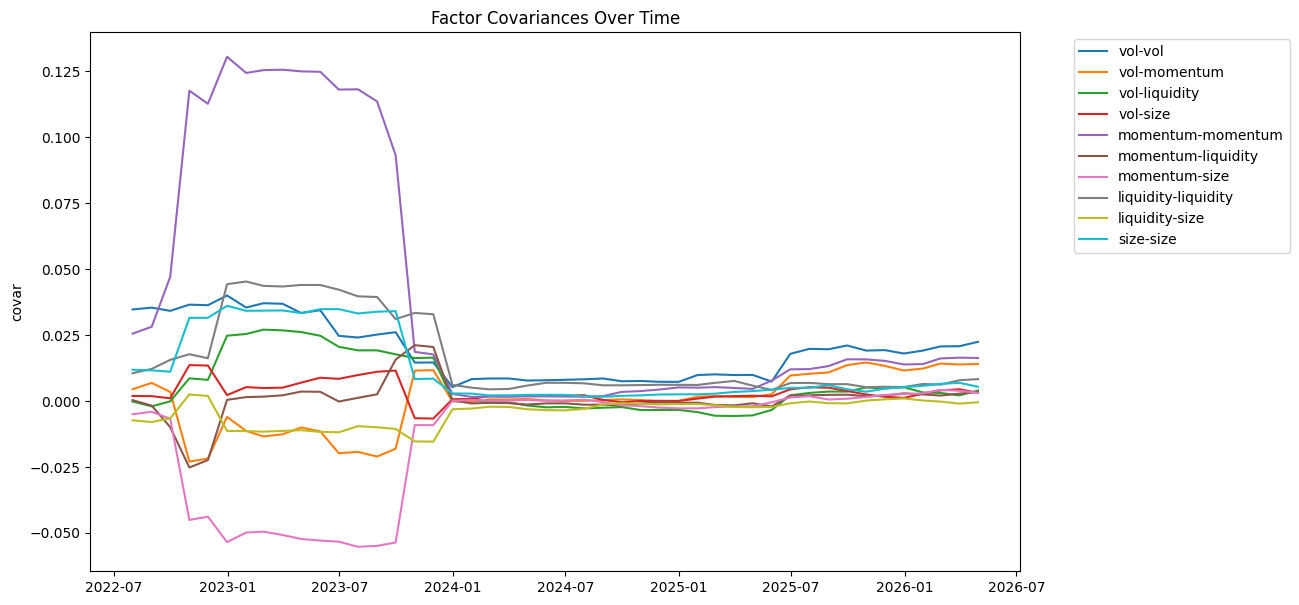

In [82]:
window = 12 
rolling_cov = factor_returns_z.rolling(window).cov() 

factors_only = factor_returns_z.drop(columns=['const','Communication Services', 'Consumer Discretionary', 
                                              'Financials', 'Health Care', 'Industrials']) 

cov_series = {} 
dates = factors_only.index[window-1:] 
factor_names = factors_only.columns 

for i in range(len(factor_names)): 
    for j in range(i, len(factor_names)): 
        f1 = factor_names[i] 
        f2 = factor_names[j] 
        
        name = f"{f1}-{f2}" 
        cov_series[name] = [ rolling_cov.loc[date].loc[f1, f2] for date in dates ] 
        
import matplotlib.pyplot as plt 
        
plt.figure(figsize=(12,7)) 
        
for name, series in cov_series.items(): 
    plt.plot(dates, series, label=name) 
            
plt.title('Factor Covariances Over Time') 
plt.ylabel('covar')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()